# Анализ bulk и single-cell RNA-seq при остром миелоидном лейкозе

Данный проект посвящен анализу bulk RNA-seq и scRNA-seq данных для изучения транскрипционных изменений в остром миелоидном лейкозе под воздействием азaцитидина (AZA). Проект основан на двух датасетах из базы данных GEO: GSE184891 (bulk RNA-seq) и GSE116256 (scRNA-seq).

# Цели и задачи

Цель:

Оценить качество bulk RNA-seq данных, выявить транскрипционные изменения в клеточной линии HL-60 под действием AZA и проанализировать гетерогенность клеток в образцах ОМЛ с помощью scRNA-seq.

Задачи:

Загрузить и подготовить bulk RNA-seq датасет GSE184891 для клеточной линии HL-60.

Провести PCA анализ, визуализировать результаты и оценить сходство биологических повторностей.

Определить, какая группа образцов наиболее отличается от контроля.

Загрузить и обработать scRNA-seq датасет GSE116256 для пациента AML314.

Провести нормализацию, отбор генов, снижение размерности (PCA, UMAP) и кластеризацию.

Интерпретировать результаты кластеризации и идентифицировать маркерные гены.

Ответить на дополнительные теоретические вопросы, связанные с анализом данных.

# Описание датасетов

1. GSE184891 (bulk RNA-seq)
(опубликован 16 октября 2021 г.)

Название: Impact of AZA on myeloid leukemia cells.

Организм: Homo sapiens.

Тип эксперимента: Профилирование экспрессии методом высокопроизводительного секвенирования.

Краткое описание: Для изучения транскрипционных изменений клеток миелоидного лейкоза при воздействии AZA использовали различные линии клеток ОМЛ, обработанные AZA в течение нескольких временных точек.

Дизайн исследования: Клеточные линии ОМЛ культивировали и обрабатывали указанной концентрацией AZA в указанные моменты времени. РНК выделяли из клеток ОМЛ в конце периода культивирования и анализировали с помощью RNA-seq.

2. GSE116256 (scRNA-seq)
(опубликован 28 февраля 2019 г.)

Название: Single-cell RNA-seq reveals AML hierarchies relevant to disease progression and immunity.

Организм: Homo sapiens.

Тип эксперимента: Профилирование экспрессии методом высокопроизводительного секвенирования на уровне единичных клеток.

Краткое описание: Исследование выявило иерархии клеток ОМЛ, значимые для прогрессирования заболевания и иммунного ответа, с использованием технологии Seq-Well scRNA-seq.

Дизайн исследования: Проанализированы аспираты костного мозга от 5 здоровых доноров, 16 пациентов с ОМЛ на момент диагностики и 19 парных образцов во время лечения.

# bulk RNA-seq (HL-60)

**Загрузили и открыли файл с исходными данными**

In [ ]:
import pandas as pd


samples_pd = pd.read_csv("GSE184891_count.txt",
                         sep="\t",
                         index_col=0,
                         header=0)

In [ ]:
samples_pd

,HL60day0Rep1,HL60day0Rep2,HL60day0Rep3,HL60day1Rep1,HL60day1Rep2,HL60day1Rep3,OCIday0rep1,OCIday0rep2,OCIday0rep3,OCIday1rep1,...,HL60day8Rep1,HL60day8Rep2,HL60day8Rep3,OCIday1rep3,OCIday4rep1,OCIday4rep2,OCIday4rep3,OCIday8rep1,OCIday8rep2,OCIday8rep3
DDX11L1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
WASH7P,90,107,82,222,223,308,77,70,133,227,...,63,57,41,69,52,77,55,38,54,73
MIR6859-1,0,4,1,6,6,5,0,1,3,5,...,0,5,5,1,1,0,0,2,0,2
MIR1302-2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FAM138A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DAZ4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
LOC102724004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SPRY3-2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VAMP7-2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Отсортировали данные, оставив только клеточную линию HL-60**

In [ ]:
hl60 = [col for col in samples_pd.columns if 'HL60' in col ]
hl60_counts = samples_pd[hl60].copy()

In [ ]:
hl60

['HL60day0Rep1',
 'HL60day0Rep2',
 'HL60day0Rep3',
 'HL60day1Rep1',
 'HL60day1Rep2',
 'HL60day1Rep3',
 'HL60day4Rep1',
 'HL60day4Rep2',
 'HL60day4Rep3',
 'HL60day8Rep1',
 'HL60day8Rep2',
 'HL60day8Rep3']

**Добавили метаданные**

In [ ]:
meta = pd.DataFrame({'sample': hl60})
meta['group'] = meta['sample'].str.extract(r'(day\d+)')[0]


In [ ]:
meta

,sample,group
0,HL60day0Rep1,day0
1,HL60day0Rep2,day0
2,HL60day0Rep3,day0
3,HL60day1Rep1,day1
4,HL60day1Rep2,day1
5,HL60day1Rep3,day1
6,HL60day4Rep1,day4
7,HL60day4Rep2,day4
8,HL60day4Rep3,day4
9,HL60day8Rep1,day8


**Сортировка и вывод полученного результата**

In [ ]:
hl60_counts = hl60_counts.loc[hl60_counts.sum(axis=1) >= 10]



In [ ]:
hl60_counts

,HL60day0Rep1,HL60day0Rep2,HL60day0Rep3,HL60day1Rep1,HL60day1Rep2,HL60day1Rep3,HL60day4Rep1,HL60day4Rep2,HL60day4Rep3,HL60day8Rep1,HL60day8Rep2,HL60day8Rep3
WASH7P,90,107,82,222,223,308,57,54,68,63,57,41
MIR6859-1,0,4,1,6,6,5,2,4,1,0,5,5
LOC101927589,5,1,2,3,19,8,3,1,7,2,10,1
LOC729737,207,151,244,649,702,884,158,221,178,201,192,213
LOC100996442,1,0,1,2,1,2,0,0,0,2,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
TMLHE-AS1,1,2,0,4,1,4,3,2,4,1,1,3
TMLHE,79,45,83,217,236,223,73,71,80,62,66,58
SPRY3,12,6,4,34,56,43,17,18,9,9,15,20
VAMP7,964,803,941,2087,2095,2305,1018,1045,1123,907,1025,1059


**Провели нормализацию**

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

cpm = hl60_counts / hl60_counts.sum(axis=0) * 1e6
vst_data = np.log1p(cpm)

**Выбрали топ-10000 генов с наибольшей дипсперсией**

In [ ]:
gene_variances = vst_data.var(axis=1)
top_10000_genes = gene_variances.nlargest(10000).index
vst_top = vst_data.loc[top_10000_genes]


**Выполнили РСА и визуализировали результаты**

In [ ]:
meta

,sample,group
0,HL60day0Rep1,day0
1,HL60day0Rep2,day0
2,HL60day0Rep3,day0
3,HL60day1Rep1,day1
4,HL60day1Rep2,day1
5,HL60day1Rep3,day1
6,HL60day4Rep1,day4
7,HL60day4Rep2,day4
8,HL60day4Rep3,day4
9,HL60day8Rep1,day8


In [ ]:
pca = PCA(n_components=5)
pca_result = pca.fit_transform(vst_top.T)

pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2', 'PC3','PC4','PC5'],
    index=hl60_counts.columns
)

sample_to_group = dict(zip(meta['sample'], meta['group']))


pca_df['group'] = pca_df.index.map(sample_to_group)

In [ ]:
pca_df

,PC1,PC2,PC3,PC4,PC5,group
HL60day0Rep1,-27.346593,-4.015706,15.905994,5.965249,0.313299,day0
HL60day0Rep2,-48.734453,-24.202736,-14.986281,-3.159957,-0.774950,day0
HL60day0Rep3,-28.535285,-4.723392,13.951208,5.485051,1.105406,day0
HL60day1Rep1,-13.661222,18.953259,-4.245959,-0.722153,-1.188830,day1
HL60day1Rep2,-10.279640,21.853430,-0.101076,0.538094,-0.657513,day1
HL60day1Rep3,-16.665928,18.294385,-9.478515,-1.615266,1.008761,day1
HL60day4Rep1,21.228861,-3.472066,6.167623,-11.402256,-6.742150,day4
HL60day4Rep2,20.248981,-2.226961,3.830067,-11.296904,3.962754,day4
HL60day4Rep3,17.768228,-6.110890,0.756746,-12.851076,3.141803,day4
HL60day8Rep1,28.816198,-4.349188,-4.670616,9.620729,7.246464,day8


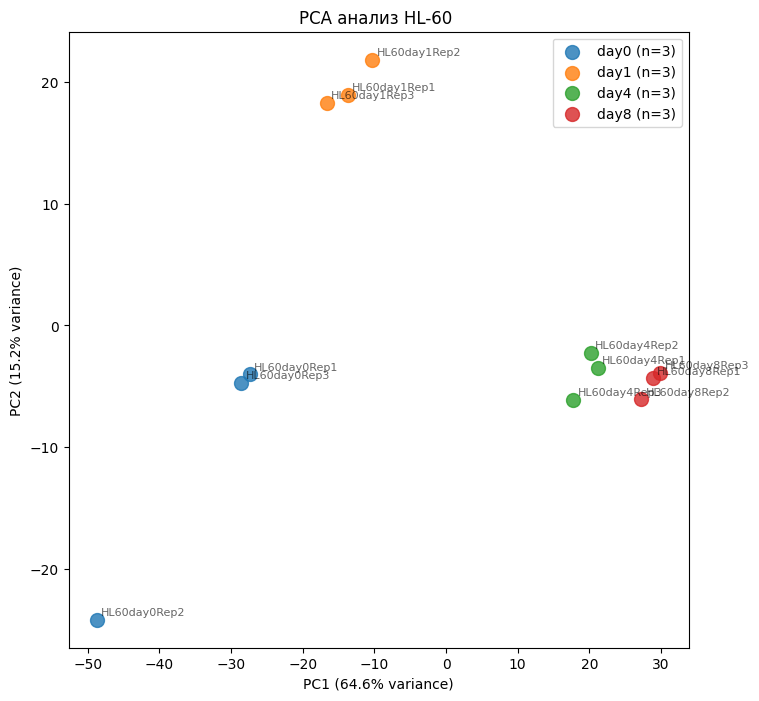

In [ ]:
plt.figure(figsize=(8, 8))

for group in sorted(pca_df['group'].unique()):
    mask = pca_df['group'] == group
    subset = pca_df[mask]

    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'{group} (n={len(subset)})',
        s=100,
        alpha=0.8
    )


    for sample in subset.index:
        plt.annotate(
            sample,
            (subset.loc[sample, 'PC1'], subset.loc[sample, 'PC2']),
            fontsize=8,
            alpha=0.6,
            xytext=(3, 3),
            textcoords='offset points'
        )


plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA анализ HL-60 ')
plt.legend()
plt.show()


In [ ]:
print("Объясненная дисперсия:")
print(f"  PC1 = {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2 = {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  PC3 = {pca.explained_variance_ratio_[2]*100:.1f}%")
print(f"  PC4 = {pca.explained_variance_ratio_[3]*100:.1f}%")
print(f"  PC5 = {pca.explained_variance_ratio_[4]*100:.1f}%")
print(f"  Сумма PC1-PC5 = {pca.explained_variance_ratio_[:5].sum()*100:.1f}%")

Объясненная дисперсия:
  PC1 = 64.6%
  PC2 = 15.2%
  PC3 = 7.0%
  PC4 = 6.2%
  PC5 = 1.3%
  Сумма PC1-PC5 = 94.3%


In [ ]:
pca_df

,PC1,PC2,PC3,PC4,PC5,group
HL60day0Rep1,-27.346593,-4.015706,15.905994,5.965249,0.313299,day0
HL60day0Rep2,-48.734453,-24.202736,-14.986281,-3.159957,-0.774950,day0
HL60day0Rep3,-28.535285,-4.723392,13.951208,5.485051,1.105406,day0
HL60day1Rep1,-13.661222,18.953259,-4.245959,-0.722153,-1.188830,day1
HL60day1Rep2,-10.279640,21.853430,-0.101076,0.538094,-0.657513,day1
HL60day1Rep3,-16.665928,18.294385,-9.478515,-1.615266,1.008761,day1
HL60day4Rep1,21.228861,-3.472066,6.167623,-11.402256,-6.742150,day4
HL60day4Rep2,20.248981,-2.226961,3.830067,-11.296904,3.962754,day4
HL60day4Rep3,17.768228,-6.110890,0.756746,-12.851076,3.141803,day4
HL60day8Rep1,28.816198,-4.349188,-4.670616,9.620729,7.246464,day8


**Рассчитали расстояние между объектами одной группы и расстояния между центроидами групп**

In [ ]:
from sklearn.metrics import pairwise_distances
pc_cols = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
def avg_within_sklearn(group):
    sub = pca_df[pca_df['group'] == group]
    arr = sub[pc_cols].values
    if len(arr) <= 1:
        return
    dist_matrix = pairwise_distances(arr)
    mask = np.triu(np.ones_like(dist_matrix, dtype=bool), k=1)
    return dist_matrix[mask].mean()

print(f"day0: {avg_within_sklearn('day0'):.4f}")
print(f"day1: {avg_within_sklearn('day1'):.4f}")
print(f"day4: {avg_within_sklearn('day4'):.4f}")
print(f"day8: {avg_within_sklearn('day8'):.4f}")

day0: 29.1561
day1: 8.3173
day4: 9.6830
day8: 9.5159


In [ ]:
centroid_day0 = pca_df[pca_df['group'] == 'day0'][pc_cols].mean().values

print(f"Центроид day0: {centroid_day0}")
print("\nРасстояния до других групп:")

for group in ['day1', 'day4', 'day8']:
    if group in pca_df['group'].unique():
        centroid = pca_df[pca_df['group'] == group][pc_cols].mean().values
        distance = np.linalg.norm(centroid_day0 - centroid)
        n_samples = len(pca_df[pca_df['group'] == group])
        print(f"  day0 → {group}: {distance:.4f} (n={n_samples})")

Центроид day0: [-34.87211041 -10.98061141   4.95697396   2.76344748   0.21458456]

Расстояния до других групп:
  day0 → day1: 38.7250 (n=3)
  day0 → day4: 56.9956 (n=3)
  day0 → day8: 64.8201 (n=3)


# Вывод


В процессе выполнения анализа bulk RNA-seq данных для клеточной линии HL-60 были последовательно выполнены следующие действия. Изначально была произведена загрузка данных из базы данных GEO по идентификатору GSE184891 с последующей фильтрацией, оставив только образцы клеточной линии HL-60. Затем была проведена предобработка данных, включая фильтрацию генов с низкой экспрессией для устранения шума и повышения качества последующего анализа. После этого данные были нормализованы. Для снижения размерности и выделения наиболее информативных генов был выполнен отбор высоковариабельных генов, после чего проведён анализ главных компонент.

Визуализация результатов PCA продемонстрировала чёткое разделение образцов по группам в зависимости от времени обработки AZA. Анализ сходства повторностей внутри групп выявил интересную закономерность: во всех обработанных группах (Day1, Day4, Day8) повторности демонстрируют высокую степень сходства. Однако в контрольной группе наблюдается значительно большее среднее расстояние между повторностями, что может указывать на большую естественную вариабельность необработанных клеток или на технические особенности контрольных образцов.

График РСА анлиза между образцами наглядно показывает, что повторности из одной экспериментальной группы образуют компактные кластеры. Особенно заметно, что все обработанные группы четко отделены от контрольной группы. Расчет расстояний между центроидами групп в PCA-пространстве подтвердил, что наибольшее отличие от контроля наблюдается у группы Day8. Интересно отметить, что расстояние между группами Day4 и Day8 значительно меньше, чем расстояния от этих групп до контроля. Это может свидетельствовать о том, что основные транскрипционные изменения происходят в первые 4 дня обработки, а к 8-му дню изменения становятся менее выраженными.

Что касается дополнительных вопросов анализа, то если PCA показывает значительное отличие между группами образцов, это действительно может быть вызвано батч-эффектом, особенно если образцы обрабатывались в разное время или разными партиями реагентов. В данном случае, учитывая последовательную временную динамику изменений (Control → Day1 → Day4 → Day8) и логическую биологическую интерпретацию (усиление эффекта AZA со временем), маловероятно, что наблюдаемые различия обусловлены исключительно батч-эффектом. Однако для полной уверенности необходима дополнительная информация о метаданных эксперимента, таких как даты проведения экспериментов, партии реагентов и другие технические параметры.

Относительно вопроса о том, зачем делают PCA перед тем как проводить tSNE или UMAP преобразование для scRNA-seq данных, следует отметить, что PCA выполняет несколько важных функций. Во-первых, он снижает размерность данных, что уменьшает вычислительную сложность последующих алгоритмов. Во-вторых, PCA выделяет наиболее информативные компоненты данных, отфильтровывая технический шум. В-третьих, методы tSNE и UMAP работают более стабильно и эффективно на PCA-редуцированных данных, так как они менее чувствительны к "проклятию размерности".

На вопрос о том, можно ли считать, что кластер 2 содержит больше дифференциально экспрессирующихся генов по сравнению с кластером 4, чем кластеры 1 и 3, основываясь только на близости на UMAP графике, следует ответить отрицательно. Близость кластеров на UMAP не обязательно коррелирует с количеством дифференциально экспрессирующихся генов или степенью их дифференциальной экспрессии. UMAP сохраняет локальные структуры данных, но может искажать глобальные расстояния между кластерами. Для точного определения количества и степени дифференциальной экспрессии генов необходимо проводить статистический анализ с использованием таких методов, как t-тест, ANOVA или непараметрические аналоги, что и было сделано в ходе анализа с использованием метода wilcoxon.

Таким образом, результаты анализа убедительно показывают, что обработка AZA вызывает временнозависимые изменения транскриптома клеток HL-60, причём наиболее выраженные отличия от контроля наблюдаются после 8 дней обработки.

# scRNA-seq (AML314)

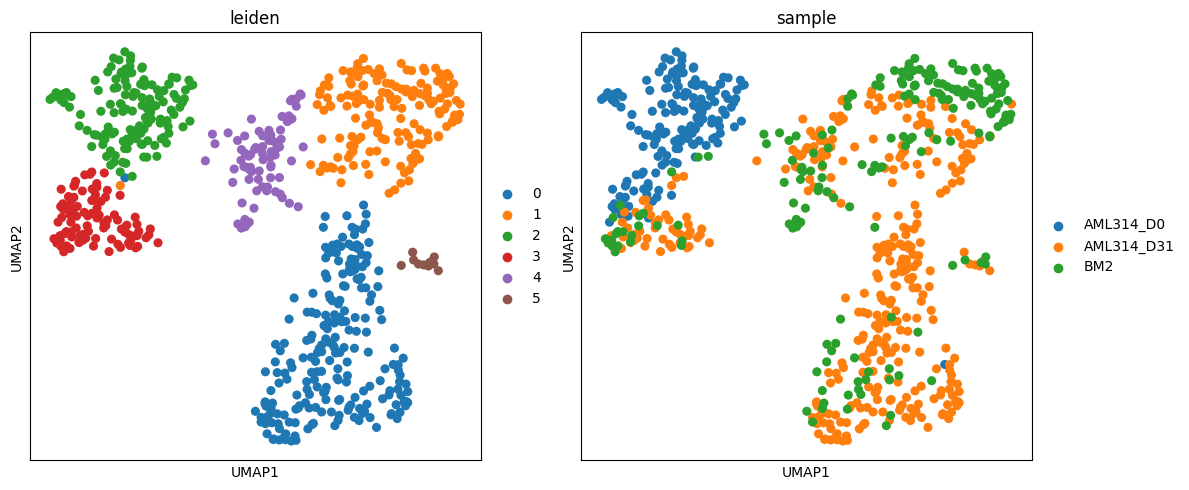

Статистика по кластерам:
Кластер 0: 220 клеток
Кластер 1: 160 клеток
Кластер 2: 136 клеток
Кластер 3: 92 клеток
Кластер 4: 77 клеток
Кластер 5: 11 клеток

Топ-3 маркерных гена для кластеров:
Кластер 0: HBB, AHSP, HBD
Кластер 1: LYZ, S100A9, MNDA
Кластер 2: RPS6, FTH1, REL
Кластер 3: ETS1, SYNE2, CD3D
Кластер 4: SPINK2, RPS6, IGLL1
Кластер 5: HSP90B1, SSR4, ANKRD36BP2


In [ ]:
!pip install scanpy harmonypy igraph leidenalg -q
import scanpy as sc
import warnings
warnings.filterwarnings('ignore')

# Загрузка и объединение данных
files = ['AML314-D0.dem.txt', 'AML314-D31.dem.txt', 'BM2.dem.txt']
dfs = []
for file in files:
    df = pd.read_csv(file, sep='\t')
    df = df.set_index('Gene')
    dfs.append(df)

merged = pd.concat(dfs, axis=1).fillna(0)
merged = merged.T

# Создание AnnData
adata_sc = sc.AnnData(merged)
adata_sc.obs['sample'] = ['AML314_D0']*162 + ['AML314_D31']*346 + ['BM2']*188
adata_sc.obs['condition'] = ['Patient_D0']*162 + ['Patient_D31']*346 + ['Healthy']*188

# Фильтрация, нормализация, PCA
sc.pp.filter_genes(adata_sc, min_cells=10)
sc.pp.normalize_total(adata_sc, target_sum=1e4)
sc.pp.log1p(adata_sc)
sc.pp.highly_variable_genes(adata_sc, n_top_genes=2000, flavor='seurat')
adata_sc = adata_sc[:, adata_sc.var['highly_variable']].copy()
sc.pp.scale(adata_sc, max_value=10)
sc.tl.pca(adata_sc, svd_solver='arpack')

# UMAP и кластеризация
sc.pp.neighbors(adata_sc, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_sc, min_dist=0.3)
sc.tl.leiden(adata_sc, resolution=0.4)

# Визуализация UMAP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.umap(adata_sc, color='leiden', ax=ax1, show=False)
sc.pl.umap(adata_sc, color='sample', ax=ax2, show=False)
plt.tight_layout()
plt.show()

# Анализ кластеров
print("Статистика по кластерам:")
for cluster in sorted(adata_sc.obs['leiden'].unique()):
    idx = adata_sc.obs['leiden'] == cluster
    n_cells = idx.sum()
    print(f"Кластер {cluster}: {n_cells} клеток")

# Маркерные гены
sc.tl.rank_genes_groups(adata_sc, groupby='leiden', method='wilcoxon')
print("\nТоп-3 маркерных гена для кластеров:")
for cluster in sorted(adata_sc.obs['leiden'].unique()):
    genes = adata_sc.uns['rank_genes_groups']['names'][cluster][:3]
    print(f"Кластер {cluster}: {', '.join(genes)}")

# Вывод

После выполнения анализа scRNA-seq данных для пациента AML314 были последовательно выполнены следующие действия.

Сначала данные были загружены из файлов, соответствующих образцам пациента на момент диагностики (AML314-D0), после лечения (AML314-D31) и здорового донора (BM2).

После объединения данных и создания AnnData объекта была проведена предобработка, включающая фильтрацию генов с низкой экспрессией, нормализацию, логарифмирование и отбор высоковариабельных генов. Затем было выполнено масштабирование данных и анализ главных компонент для снижения размерности.

После этого был построен граф соседей, выполнено UMAP-преобразование для визуализации и проведена кластеризация методом Leiden.

В результате кластеризации было идентифицировано шесть кластеров клеток. Статистика по кластерам показала, что кластер 0 является самым крупным и содержит преимущественно клетки из образца после лечения, кластер 1 состоит из клеток здорового донора и образца после лечения, кластер 2 почти исключительно представлен клетками на момент диагностики, кластер 3 содержит клетки из всех трёх образцов, кластер 4 состоит из клеток после лечения и здорового донора, а кластер 5 — наименьший, содержащий клетки после лечения и здорового донора.

Анализ маркерных генов позволил предположить клеточную принадлежность кластеров: кластер 0 обогащён генами гемоглобина (HBB, AHSP, HBD), что указывает на эритроидные клетки; кластер 1 экспрессирует гены, характерные для миелоидных клеток (LYZ, S100A9, MNDA); кластер 2 демонстрирует высокую экспрессию генов, связанных с рибосомами и метаболизмом (RPS6, FTH1, REL); кластер 3 содержит гены, ассоциированные с лимфоидными клетками (CD3D) и регуляцией транскрипции (ETS1); кластер 4 включает гены, участвующие в иммунном ответе и развитии лимфоцитов (SPINK2, IGLL1); кластер 5 характеризуется генами, связанными с ответом на стресс и процессингом белков (HSP90B1, SSR4).

Что касается дополнительных вопросов, то PCA перед UMAP выполняется для снижения шума и размерности данных, что ускоряет вычисления и улучшает качество визуализации. Близость кластеров на UMAP не всегда прямо коррелирует с количеством дифференциально экспрессируемых генов, так как UMAP сохраняет локальные структуры, но может искажать глобальные расстояния; для точных выводов необходимо проводить статистический анализ дифференциальной экспрессии. Таким образом, анализ выявил гетерогенность клеточного состава в образцах пациента с ОМЛ и позволил идентифицировать различные клеточные популяции, что важно для понимания биологии заболевания и потенциальных терапевтических мишеней.